# 01. Limpieza y EDA de Datos

**Objetivo:** explorar y limpiar notas clínicas IPS para construir el dataset textual base.
**Entradas:** `data/ips_raw.csv`.
**Salidas:** `data/ips_clean.csv`.
**Notebook anterior:** ninguno (inicio del pipeline).
**Notebook siguiente:** `notebooks/pipeline/02_patient_level_split.ipynb`.


In [1]:
import sys
import re
import unicodedata
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar utilidades compartidas del proyecto
sys.path.insert(0, str(Path.cwd().resolve()))
from utils_shared import (
    setup_paths, validate_file_exists, guess_text_col, 
    guess_label_col, normalize_label
)

# Configurar visualizaciones para reportes metodológicos
pd.set_option('display.max_colwidth', 120)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.figsize': (10, 6)})

paths = setup_paths()
DATA_PATH = paths['DATA_PATH']
FIGS_PATH = paths['FIGS_PATH']
RAW_FILE  = DATA_PATH / 'ips_raw.csv'

print("Herramientas cargadas correctamente.")


Herramientas cargadas correctamente.


## 1. Cargar el Archivo Original
Extraemos las notas clínicas tal como salieron de la base de datos.


In [2]:
validate_file_exists(RAW_FILE, 'Error: falta el archivo ips_raw.csv en la carpeta data.')
df_raw = pd.read_csv(RAW_FILE)

print(f"Tenemos {df_raw.shape[0]} notas y {df_raw.shape[1]} columnas de información.")
display(df_raw.head(3))


Tenemos 3155 notas y 10 columnas de información.


,Archivo,Prontuario,Nombre Paciente,Sexo,Fecha Nacimiento,N° Consulta,Id,Fecha Consulta,Motivo Consulta,Tipo
0,1060906.pdf,406231,RODRIGUEZ DE BRITEZ(E,Feminino,15/11/1964,1,1,16/05/2025,Reposicion de medicacion 2) EXAMEN FISICO GRAL. Y GINECOLOGICO PESO ( ) TALLA ( ) PRESION ARTERIAL ( ) PULSO ( ) TEM...,ansiedad
1,1060906.pdf,406231,RODRIGUEZ DE BRITEZ(E,Feminino,15/11/1964,2,1,14/04/2025,acude para reposicion 2) EXAMEN FISICO GRAL. Y GINECOLOGICO PESO ( ) TALLA ( ) PRESION ARTERIAL ( ) PULSO ( ) TEMPER...,ansiedad
2,1060906.pdf,406231,RODRIGUEZ DE BRITEZ(E,Feminino,15/11/1964,3,1,19/03/2025,"Se encuentra estable, tranquila, refiere buen animo. Mejoria de sintomas Se encuentra estable, tranquila, refiere bu...",ansiedad


## 2. Detectar Columnas Importantes
Nuestro sistema revisa cuáles columnas contienen el texto escrito por el médico, el diagnóstico principal, y el código de identificación del paciente.


In [3]:
text_col  = guess_text_col(df_raw)
label_col_raw = guess_label_col(df_raw)

# Estandarizar nombres de etiqueta (por ejemplo, 'ansiedad' o 'depresion')
df_raw['etiqueta'] = df_raw[label_col_raw].apply(normalize_label)

# Detectar ID del paciente
patient_col = None
for col in ['patient_id', 'id_paciente', 'paciente', 'Prontuario']:
    if col in df_raw.columns:
        patient_col = col
        break

print(f"Columna de texto clínico: '{text_col}'")
print(f"Columna de diagnóstico: '{label_col_raw}' (normalizada como 'etiqueta')")
print(f"Columna de identificador de paciente: '{patient_col}'")


Columna de texto clínico: 'Motivo Consulta'
Columna de diagnóstico: 'Tipo' (normalizada como 'etiqueta')
Columna de identificador de paciente: 'Prontuario'


Gráfico de proporción de diagnósticos:


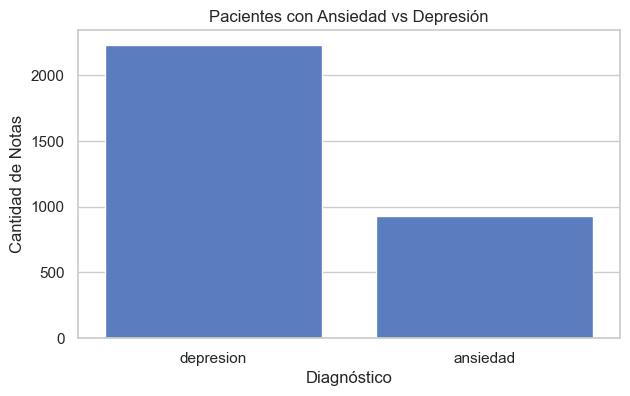

In [4]:
print("Gráfico de proporción de diagnósticos:")

plt.figure(figsize=(7, 4))
sns.countplot(data=df_raw, x='etiqueta', order=df_raw['etiqueta'].value_counts().index)
plt.title('Pacientes con Ansiedad vs Depresión')
plt.ylabel('Cantidad de Notas')
plt.xlabel('Diagnóstico')
plt.show()


### 2.1 Estadísticas de Longitud de los Textos
Comprender qué tan largas son las notas es vital, porque los modelos de Inteligencia Artificial tienen un límite de cuánto texto pueden leer de una sola vez.


,longitud_char,longitud_word
count,3155.0,3155.0
mean,1882.0,311.6
std,2982.3,503.8
min,3.0,1.0
25%,461.0,72.0
50%,765.0,126.0
75%,2110.0,348.0
90%,4257.6,728.6
95%,6742.6,1107.7
99%,14978.6,2624.3


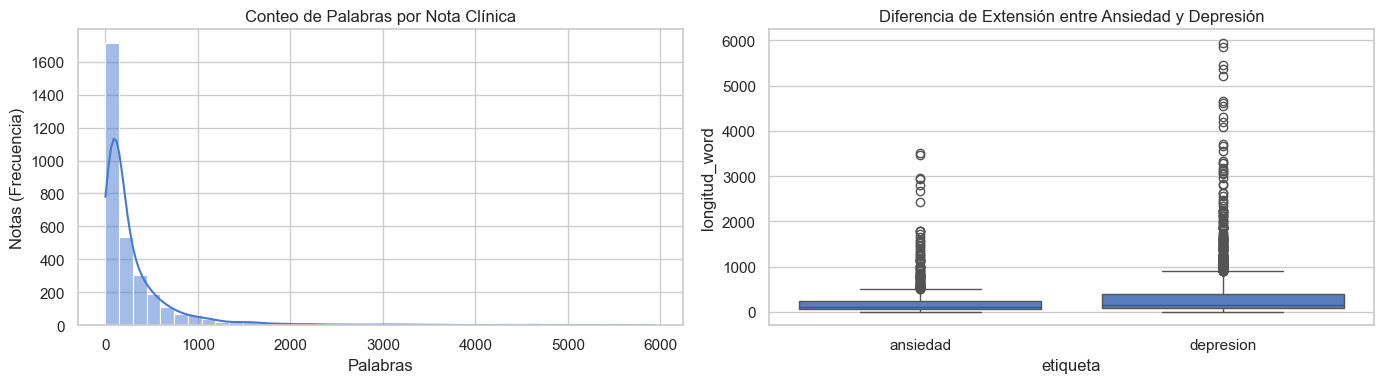

In [5]:
df_raw['longitud_char'] = df_raw[text_col].astype(str).apply(len)
df_raw['longitud_word'] = df_raw[text_col].astype(str).apply(lambda x: len(x.split()))

display(df_raw[['longitud_char', 'longitud_word']].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).round(1))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(df_raw['longitud_word'], bins=40, kde=True, ax=axes[0])
axes[0].set_title('Conteo de Palabras por Nota Clínica')
axes[0].set_xlabel('Palabras')
axes[0].set_ylabel('Notas (Frecuencia)')

sns.boxplot(x='etiqueta', y='longitud_word', data=df_raw, ax=axes[1])
axes[1].set_title('Diferencia de Extensión entre Ansiedad y Depresión')
plt.tight_layout()
plt.show()


## 3. Limpieza de Texto (Evitar confusión en la máquina)
A veces escribimos de prisa en los historiales clínicos. La siguiente función corrige letras repetidas excesivamente, quita emojis, y repara problemas comunes (como tildes raras) usando reglas estándar (NFC Unicode).


In [6]:
# Herramienta para detectar letras que se repiten 3 o más veces seguidas y convertirlas en 2.
# (Ejemplo: 'siiiii' se convierte en 'sii')
_RE_MULTI = re.compile(r'(.)\1{2,}')

def clean_text_eda(s: str) -> str:
    if pd.isna(s):
        return ''
    s = str(s).strip()
    s = unicodedata.normalize('NFC', s) # Normalizar acentos
    s = _RE_MULTI.sub(r'\1\1', s)
    # Mantener solo letras, números y signos de puntuación básicos
    s = re.sub(r'[^0-9A-Za-zÁÉÍÓÚÜÑáéíóúüñ \t\n\r.,;:!?()\-/%+]', ' ', s)
    s = re.sub(r'\s+', ' ', s).strip()
    return s

df_raw['text_clean'] = df_raw[text_col].apply(clean_text_eda)


## 4. Retirar Oraciones Importadas (Copiar y Pegar)
Hacemos un filtro para que si dentro de la misma consulta la misma oración exacta está dos veces, se borre la copia y solo se lea una vez. Esto reduce peso inútil.


In [7]:
def remove_duplicate_sentences(text: str) -> str:
    if pd.isna(text) or not text.strip():
        return ''
    sents = text.split('. ')
    seen = set()
    unique_sents = []
    for s in sents:
        s_clean = s.strip()
        if s_clean and s_clean not in seen:
            seen.add(s_clean)
            unique_sents.append(s)
    return '. '.join(unique_sents)

df_raw['text_dedup'] = df_raw['text_clean'].apply(remove_duplicate_sentences)

df_raw['len_orig']  = df_raw['text_clean'].apply(len)
df_raw['len_dedup'] = df_raw['text_dedup'].apply(len)
reduction = 100 * (1 - df_raw['len_dedup'].sum() / (df_raw['len_orig'].sum() + 1e-9))

print(f'Impacto de remover duplicados exactos: reducción de {reduction:.2f}% del texto redundante.')


Impacto de remover duplicados exactos: reducción de 38.17% del texto redundante.


In [8]:
initial_rows = len(df_raw)
cols_subset  = [patient_col, 'Fecha Consulta', 'text_dedup'] if (patient_col and 'Fecha Consulta' in df_raw.columns) else ['text_dedup']

df_clean = df_raw.drop_duplicates(subset=cols_subset).copy()
filas_cargadas = initial_rows - len(df_clean)

print(f"Se eliminaron {filas_cargadas} registros duplicados completos.")
print(f'Total final para análisis: {len(df_clean)} notas clínicas.')


Se eliminaron 12 registros duplicados completos.
Total final para análisis: 3143 notas clínicas.


### Analisis Notas con bloque plantilla


In [9]:
import re

START_RE = re.compile(r"(?is)\b2\)\s*examen\s+fisico\s+gral\.?(?:\s+y\s+ginecologico)?")

df_clean["feat_had_template_block"] = df_clean["text_dedup"].astype(str).str.contains(
    START_RE, regex=True
).astype(int)

pct = 100 * df_clean["feat_had_template_block"].mean()
n = int(df_clean["feat_had_template_block"].sum())
N = len(df_clean)

print(f"Notas con bloque plantilla (detectado por '2) EXAMEN FISICO GRAL'): {n}/{N} = {pct:.2f}%")

# (Opcional) visualizar ejemplos
examples = df_clean.loc[df_clean["feat_had_template_block"] == 1, "text_dedup"].head(3).tolist()
for i, ex in enumerate(examples, 1):
    print(f"\n--- EJEMPLO {i} ---\n{ex[:400]}...")

Notas con bloque plantilla (detectado por '2) EXAMEN FISICO GRAL'): 2521/3143 = 80.21%

--- EJEMPLO 1 ---
Reposicion de medicacion 2) EXAMEN FISICO GRAL. Y GINECOLOGICO PESO ( ) TALLA ( ) PRESION ARTERIAL ( ) PULSO ( ) TEMPERATURA ( ) 3) METODOS AUXILIARES -- 4) DIAGNOSTICO PRESUNTIVO -- 5) TRATAMIENTO CLINICO-OTROS -- 6) PESO -- 7) PULSO -- 8) OBSERVACION -- / ROTELA DE KERMENGUY, ARIANA Carimbo / Assinatura Emiss o 14/06/2025 09:54 Ficha 31 1 Página AMBULATORIO 10947615 Pront.: RODRIGUEZ DE BRITEZ(E...

--- EJEMPLO 2 ---
acude para reposicion 2) EXAMEN FISICO GRAL. Y GINECOLOGICO PESO ( ) TALLA ( ) PRESION ARTERIAL ( ) PULSO ( ) TEMPERATURA ( ) 3) METODOS AUXILIARES -- 4) DIAGNOSTICO PRESUNTIVO -- 5) TRATAMIENTO CLINICO-OTROS -- 6) PESO -- 7) PULSO -- 8) OBSERVACION -- / CUEVAS ALMANDO, ANDREA CELESTE Carimbo / Assinatura Emiss o 14/06/2025 09:54 Ficha 31 1 Página AMBULATORIO 10947615 Pront.: RODRIGUEZ DE BRITEZ(E...

--- EJEMPLO 3 ---
reposicion segun indicaciones de tratante 2) EXA

####  Normalización del formato de nota (muy común en EHR)


In [10]:

# ============================================================
# Normalización del formato de nota (muy común en EHR)
# ------------------------------------------------------------
# Identificamos y eliminamos segmentos de formulario repetitivos
# (secciones 2–8) que no aportan fenomenología psiquiátrica y
# generan falsos positivos en extracción basada en reglas.
# Esto corresponde a limpieza de datos, no a decisión clínica.
# ============================================================

# Bloque plantilla IPS:
# inicia con "2) EXAMEN FISICO GRAL" (puede variar mínimamente)
# termina en "Paciente: XXXXX" (puede venir con números)
START_RE = re.compile(r"(?is)\b2\)\s*examen\s+fisico\s+gral\.?(?:\s+y\s+ginecologico)?")
END_RE   = re.compile(r"(?is)\bpaciente\s*:\s*[0-9]+")

def strip_ips_template_block(text: str) -> str:
    """
    Elimina SOLO el bloque de plantilla desde:
      '2) EXAMEN FISICO GRAL...' hasta 'Paciente: <id>'
    Conserva lo que viene antes y lo que viene después.
    """
    if text is None:
        return ""
    t = str(text)

    start = START_RE.search(t)
    if not start:
        return t  # no hay plantilla → no tocamos

    # Buscar el final del bloque a partir del inicio detectado
    end = END_RE.search(t, pos=start.start())
    if not end:
        # Si no aparece cierre explícito, recortar desde el inicio de la plantilla
        return t[:start.start()].strip()

    # `end.end()` incluye el segmento "Paciente: ####"
    cleaned = (t[:start.start()] + " " + t[end.end():]).strip()
    # Normalización ligera de espacios
    cleaned = re.sub(r"\s{2,}", " ", cleaned)
    return cleaned

# Aplicar transformación a `df_clean`
df_clean["texto"] = df_clean["text_dedup"].astype(str).apply(strip_ips_template_block)

# (Opcional) bandera útil para análisis posterior
df_clean["feat_had_template_block"] = df_clean["text_dedup"].astype(str).str.contains(
    r"(?is)\b2\)\s*examen\s+fisico\s+gral", regex=True
).astype(int)

print("Ejemplo antes/después:")
idx = df_clean.index[0]
print("ANTES:", df_clean.loc[idx, "text_dedup"][:250], "...\n")
print("DESPUÉS:", df_clean.loc[idx, "texto"][:250], "...")

Ejemplo antes/después:
ANTES: Reposicion de medicacion 2) EXAMEN FISICO GRAL. Y GINECOLOGICO PESO ( ) TALLA ( ) PRESION ARTERIAL ( ) PULSO ( ) TEMPERATURA ( ) 3) METODOS AUXILIARES -- 4) DIAGNOSTICO PRESUNTIVO -- 5) TRATAMIENTO CLINICO-OTROS -- 6) PESO -- 7) PULSO -- 8) OBSERVACI ...

DESPUÉS: Reposicion de medicacion ...


## 5. Exportar el Archivo Limpio
Todo este proceso se guarda en `ips_clean.csv`, listo para dividir a los pacientes en el siguiente paso.


In [11]:
out_file = DATA_PATH / 'ips_clean.csv'
columns_to_keep = [c for c in [patient_col, 'etiqueta', 'texto', 'feat_had_template_block'] if c in df_clean.columns]

df_export = df_clean[columns_to_keep].rename(columns={patient_col: 'patient_id'})
df_export.to_csv(out_file, index=False)

print(f'Datos guardados en: {out_file.name}')


Datos guardados en: ips_clean.csv
